子代理

In [55]:
from datetime import datetime
from langchain.agents import AgentState
from typing import TypedDict, NotRequired, Annotated
from langchain_core.messages import ToolMessage
from langgraph.types import Command


class Todo(TypedDict):
    content: str


def file_reducer(left, right):
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}


class DeepAgentState(AgentState):
    todos: NotRequired[list[Todo]]
    files: NotRequired[Annotated[dict[str, str], file_reducer]]
    remaining_steps: NotRequired[int]


In [56]:
from langchain_core.tools import tool, BaseTool, InjectedToolCallId
from typing_extensions import TypedDict
from langgraph.prebuilt import InjectedState, create_react_agent
from deep_agent_from_search.prompt import TASK_DESCRIPTION_PREFIX, SUBAGENT_USAGE_INSTRUCTIONS


class SubAgent(TypedDict):
    """专业子代理的配置"""
    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    agents = {}
    tools_by_name = {}

    # 1. 整理工具
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    # 2. 创建子 Agent
    for _agent in subagents:
        if "tools" in _agent:
            _tools = [tools_by_name[name] for name in _agent["tools"]]
        else:
            _tools = tools

        agents[_agent["name"]] = create_react_agent(
            model=model,
            prompt=_agent["prompt"],
            tools=_tools,
            state_schema=state_schema,
        )

    print("已经创建的子 Agent：", agents.keys())

    other_agents_string = [
        f"- {_agent['name']}: {_agent['description']}"
        for _agent in subagents
    ]

    # 3. 创建 task 工具
    @tool(
        description=TASK_DESCRIPTION_PREFIX.format(
            other_agents=other_agents_string
        )
    )
    def task(
            description: str,
            subagent_type: str,
            state: Annotated[DeepAgentState, InjectedState],
            tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        print("\n========== 进入 task ==========")
        print("description =", description)
        print("subagent_type =", subagent_type)
        print("tool_call_id =", tool_call_id)
        print("tool_call_id type =", type(tool_call_id))
        print("state keys =", state.keys())

        # 4. 判断子 Agent 是否存在
        if subagent_type not in agents:
            return f""" Error: 调用的代理类型为 {subagent_type} 允许的代理类型为 {list(agents.keys())} """

        sub_agent = agents[subagent_type]

        try:
            # 5. 给子 Agent 创建独立 State
            sub_state = {
                **state,
                "messages": [
                    {
                        "role": "user",
                        "content": description,
                    }
                ],
            }

            print("\n========== 准备调用子 Agent ==========")
            print("sub_state =", sub_state)

            # 6. 真正调用子 Agent
            result = sub_agent.invoke(sub_state)

            print("\n========== 子 Agent 执行完成 ==========")
            print("result keys =", result.keys())
            print("result messages =", result["messages"])

            # 7. 获取子 Agent 最终答案
            final_message = result["messages"][-1]

            print("\n========== 子 Agent 最终结果 ==========")
            print(final_message)
            print("content =", final_message.content)

            # 8. 返回给父 Agent
            return Command(
                update={
                    "files": result.get("files", {}),
                    "messages": [
                        ToolMessage(
                            content=final_message.content,
                            tool_call_id=tool_call_id,
                        )
                    ],
                }
            )

        except Exception as e:
            import traceback

            print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
            print("TASK 真正异常：")
            print(repr(e))
            print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

            traceback.print_exc()

            raise

    return task

C:\Users\TaoYu\AppData\Local\Temp\ipykernel_35112\356600506.py:32: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agents[_agent["name"]] = create_react_agent(
C:\Users\TaoYu\AppData\Local\Temp\ipykernel_35112\1717249577.py:35: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


已经创建的子 Agent： dict_keys(['research_agent'])


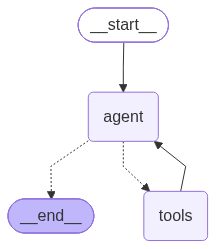

In [57]:
from IPython.display import Image, display
from langchain_openai.chat_models import ChatOpenAI
from Config.load_key import base_url, base_model, open_key

max_concurrent_research_units = 3
max_researcher_iterations = 3

search_result = "模型上下文协议（mcp）是有Anthropic开发的一项开放标准协议，旨在实现AI模型与外部系统（如工具，数据库及其他服务）之间的无缝链接。它充当一种标准化的通信层，是AI模型能够以一致且高效的方式访问并利用来自不同来源的数据，从根本上说，MCP通过提供一种统一的数据交换语言，简化了将AI助手与外部服务进行链接的过程"


@tool(description="搜索结果")
def web_search(
        query: str):
    return search_result


SIMPlE_RESEARCH_PROMPT = """你是一名研究人员。请研究提供给你的主题。重要提示：只需调用一次web_search工具，并使用该工具提供的结果来回答所给的主题。"""

research_sub_agent = {
    "name": "research_agent",
    "description": "将研究任务委托给子代理的研究员。每次只给这位研究员一个研究主题",
    "prompt": SIMPlE_RESEARCH_PROMPT,
    "tools": ['web_search'],
}
model = ChatOpenAI(
    model=base_model,
    base_url=base_url,
    api_key=open_key
)
sub_agent_tools = [web_search]
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)
delegation_tools = [task_tool]
agent = create_react_agent(
    model=model,
    tools=delegation_tools,
    prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%Y%m%d"),
    ),
    state_schema=DeepAgentState,
)
display(Image(agent.get_graph().draw_mermaid_png()))

In [59]:
from utils import print_stream_chunk

result = agent.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "帮我总结一下mcp服务的"
            }
        ],
        "files": {}
    }
)
for chunk in result:
    print('===' * 40)
    print_stream_chunk(chunk)


📌 节点：agent
🔧 调用工具：task
   参数：{'description': '研究并总结MCP（Model Context Protocol）服务的核心概念、主要功能、应用场景以及其在AI生态系统中的作用。', 'subagent_type': 'research_agent'}

========== 进入 task ==========
description = 研究并总结MCP（Model Context Protocol）服务的核心概念、主要功能、应用场景以及其在AI生态系统中的作用。
subagent_type = research_agent
tool_call_id = call_11ffeee3706146bd9a52708d
tool_call_id type = <class 'str'>
state keys = dict_keys(['messages', 'files'])

========== 准备调用子 Agent ==========
sub_state = {'messages': [{'role': 'user', 'content': '研究并总结MCP（Model Context Protocol）服务的核心概念、主要功能、应用场景以及其在AI生态系统中的作用。'}], 'files': {}}

========== 子 Agent 执行完成 ==========
result keys = dict_keys(['messages', 'files'])
result messages = [HumanMessage(content='研究并总结MCP（Model Context Protocol）服务的核心概念、主要功能、应用场景以及其在AI生态系统中的作用。', additional_kwargs={}, response_metadata={}, id='65c0a2cd-224f-4403-a821-16a0eae66674'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens'